In [248]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [249]:
shovel = "Shovel"
cube = "Cube"

c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"

conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_key = 'GSR Resistance CAL'
gsc_key = 'GSR Conductance CAL'

imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_key, gsc_key]

baseline_ms = 30_000

In [250]:
def get_df(p, e, c, s):
    path = './' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df):
    return df[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        return df[(df["cube_max_target_reached"] == 4)][unity_unix_key].min()
    else:
        return df[(df["collision_or_load_count"] == 20)][(df["shovel_loaded_state"] == False)][unity_unix_key].min()

def trim_imot(df, task_start, task_end):
    min_ts = task_start - baseline_ms
    max_ts = task_end + baseline_ms

    imot_start = df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    return df[(imot_start + df[imot_delta_ms_key] >= min_ts)][(imot_start + df[imot_delta_ms_key] <= max_ts)]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    start = task_start(unity_raw)
    end = task_end(unity_raw, e)

    return {
        imot: trim_imot(imot_raw, start, end),
        unity: unity_raw,
        start_ts: start,
        end_ts: end
    }

def get_experiment(p, e):
    return {
            c_0: get_condition(p, e, c_0),
            c_1: get_condition(p, e, c_1),
            c_2: get_condition(p, e, c_2),
            p_0: get_condition(p, e, p_0),
            p_1: get_condition(p, e, p_1),
            p_2: get_condition(p, e, p_2),
        }

def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel)
    }

In [251]:
cohort = [
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    "7_KlMe",
    "8_JuUe",
    ]

In [252]:
data = list(map(lambda x: get_participant(x), cohort))

C:\Users\elias\AppData\Local\Temp\ipykernel_5704\1011704658.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[(imot_start + df[imot_delta_ms_key] >= min_ts)][(imot_start + df[imot_delta_ms_key] <= max_ts)]
C:\Users\elias\AppData\Local\Temp\ipykernel_5704\1011704658.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[(imot_start + df[imot_delta_ms_key] >= min_ts)][(imot_start + df[imot_delta_ms_key] <= max_ts)]
C:\Users\elias\AppData\Local\Temp\ipykernel_5704\1011704658.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[(imot_start + df[imot_delta_ms_key] >= min_ts)][(imot_start + df[imot_delta_ms_key] <= max_ts)]
C:\Users\elias\AppData\Local\Temp\ipykernel_5704\1011704658.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[(imot_start + df[imot_delta_ms_key] >= min_ts)][(imot_start + df[imot_delta_ms_key] <= max_t

In [253]:
data[2][shovel][c_0][imot].head(3)

,System Timestamp CAL,Timestamp,Heart rate,GSR Resistance CAL,GSR Conductance CAL
565,1.750683e+12,4378,NaN,59.579805,16.784211
566,1.750683e+12,4385,NaN,59.450704,16.820659
567,1.750683e+12,4393,NaN,59.450704,16.820659


In [254]:
max_z_score = 3

def single_median(df, key):
    cleaned = df.dropna(subset = key)
    smoothed = cleaned[np.abs(stats.zscore(cleaned[key])) < max_z_score]
    return smoothed[key].median()

def plot_experiments(cube_values, shovel_values, title, ylabel):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    labels = conditions

    max_value = max(max(cube_values), max(shovel_values))
    min_value = min(min(cube_values), min(shovel_values))

    ylim = [min_value*0.9,max_value*1.1]

    axs[0].bar(labels, cube_values, color=colors)
    axs[0].set_title('[Cube] ' + title)
    axs[0].set_ylabel(ylabel)
    #axs[0].set_ylim(ylim)

    axs[1].bar(labels, shovel_values, color=colors)
    axs[1].set_title('[Shovel] ' + title)
    axs[1].set_ylabel(ylabel)
    #axs[0].set_ylim(ylim)

    plt.show()

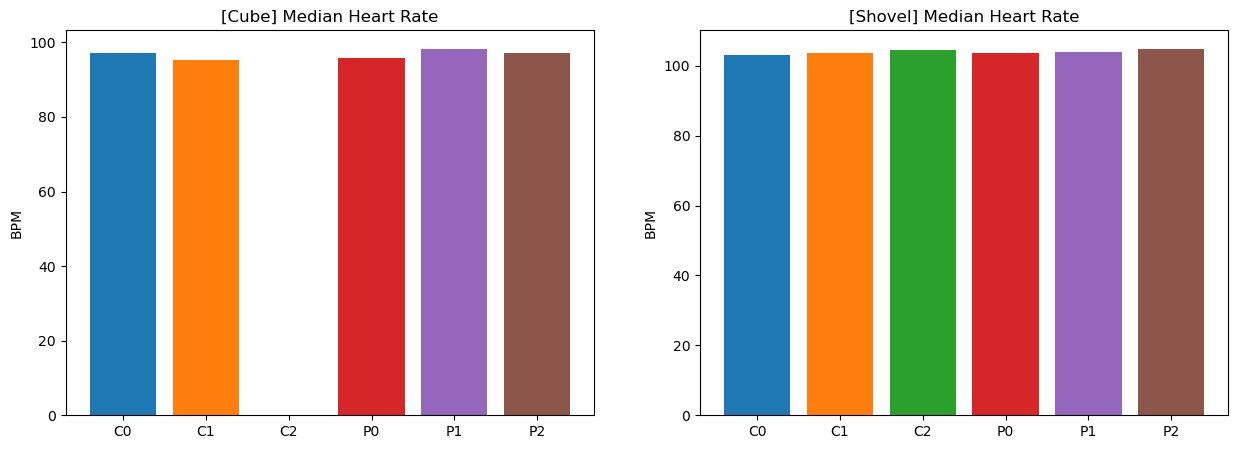

In [255]:
def agg_hr(data, e, c):
    dfs = list(map(lambda x: x[e][c][imot], data))
    single_values = list(map(lambda x: single_median(x, hr_key), dfs))
    return np.mean(single_values)

labels = conditions
cube_values = list(map(lambda x: agg_hr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_hr(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Median Heart Rate',
    ylabel= 'BPM'
    )

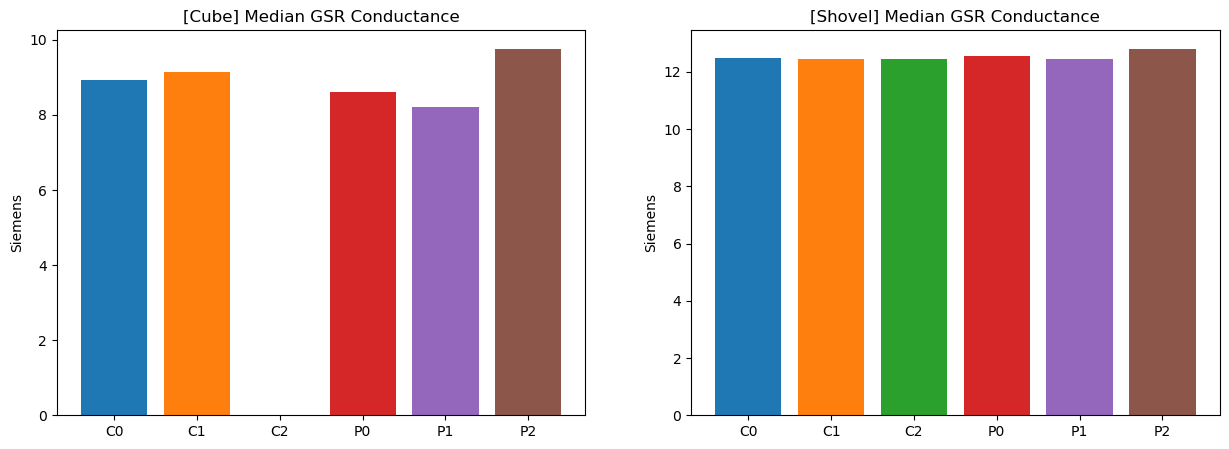

In [256]:
def agg_gsc(data, e, c):
    dfs = list(map(lambda x: x[e][c][imot], data))
    single_values = list(map(lambda x: single_median(x, gsc_key), dfs))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_gsc(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsc(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Median GSR Conductance',
    ylabel= 'Siemens'
    )

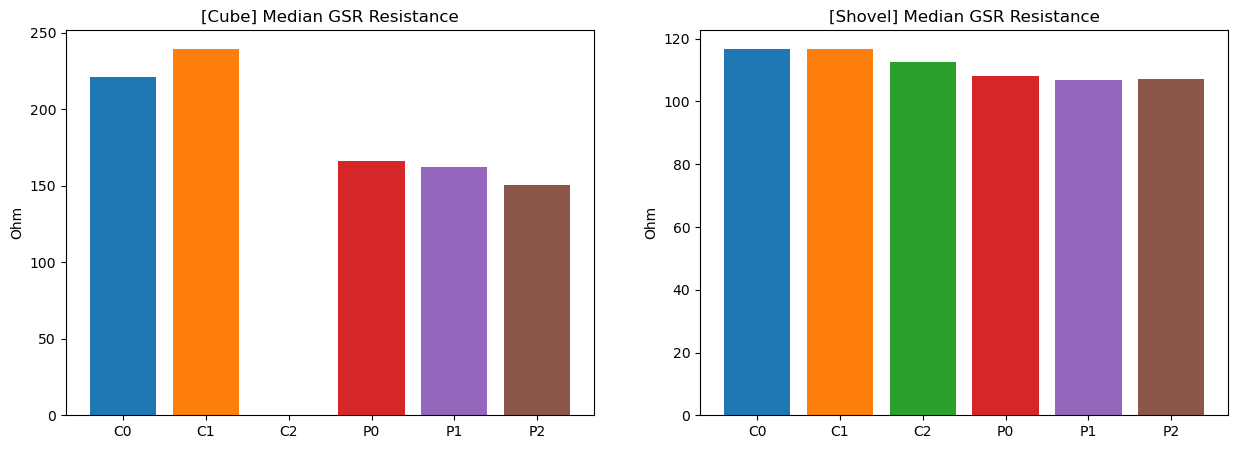

In [257]:
def agg_gsr(data, e, c):
    dfs = list(map(lambda x: x[e][c][imot], data))
    single_values = list(map(lambda x: single_median(x, gsr_key), dfs))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_gsr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsr(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Median GSR Resistance',
    ylabel= 'Ohm'
    )

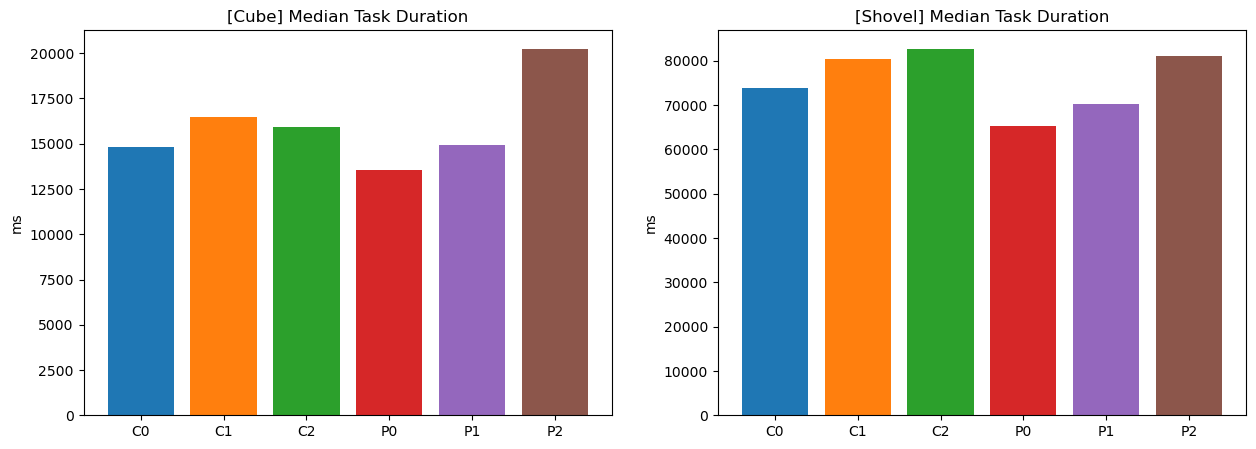

In [258]:
def single_duration(p):
    return p[end_ts] - p[start_ts]

def agg_duration(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(single_duration, participants))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_duration(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_duration(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Median Task Duration',
    ylabel= 'ms'
    )